# 04 — Agent 2: Conversion Predictor

**Models compared**:
- Baseline CatBoost (SMOTE + Balanced weights)
- Focal-inspired CatBoost (hard-example reweighting via Lin et al. 2017)
- PU-style CatBoost (positives + reliable negatives via du Plessis et al. 2015)

**22% class imbalance handling** (explicit):
- SMOTE oversampling (Chawla et al. 2002)
- CatBoost `auto_class_weights="Balanced"`
- Focal-loss sample reweighting (alpha/gamma)
- PU reliable-negative filtering
- Guardrailed threshold optimization (Saito & Rehmsmeier 2015)

**Domain features engineered**:
- `affordability_ratio`: salary-to-coverage gap
- `hh_need`: household driver demand
- `risk_coverage_fit`: risk tier × coverage interaction

**Target**: Policy_Bind (Yes=1/No=0)
**Output**: bind_score (0-100) — pure ML probability
**Explainability**: SHAP + LIME + Anchors + DiCE

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import os

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
sns.set_theme(style="whitegrid")

MODELS_DIR = Path("../models")
train_df = pd.read_parquet(MODELS_DIR / "train.parquet")
test_df = pd.read_parquet(MODELS_DIR / "test.parquet")
feature_config = joblib.load(MODELS_DIR / "feature_config.joblib")

BASE_FEATURES = feature_config["AGENT2_FEATURES"]
TARGET = "Policy_Bind_enc"


def add_domain_features(df: pd.DataFrame) -> pd.DataFrame:
    """Engineer domain-knowledge features so CatBoost learns the weights from data."""
    out = df.copy()

    # Affordability: salary band (0-4) vs coverage level (0-2)
    if "Sal_Range_enc" in out.columns and "Coverage_enc" in out.columns:
        out["affordability_ratio"] = (out["Sal_Range_enc"] / 4.0) - (out["Coverage_enc"] / 2.0)

    # Household need: more drivers = more need for a policy
    if "HH_Drivers" in out.columns:
        out["hh_need"] = np.clip(out["HH_Drivers"] - 1, 0, 3) / 3.0

    # Risk-coverage fit: LOW risk + basic coverage = good deal
    # Encodes the interaction as a single ordinal: 0=best fit, higher=worse
    if "risk_tier_enc" in out.columns and "Coverage_enc" in out.columns:
        out["risk_coverage_fit"] = out["risk_tier_enc"] + out["Coverage_enc"]

    return out


train_df = add_domain_features(train_df)
test_df = add_domain_features(test_df)

ENGINEERED = [c for c in ["affordability_ratio", "hh_need", "risk_coverage_fit"] if c in train_df.columns]
FEATURES = BASE_FEATURES + ENGINEERED

X_train = train_df[FEATURES].copy()
y_train = train_df[TARGET].copy()
X_test = test_df[FEATURES].copy()
y_test = test_df[TARGET].copy()

print(f"Base features:       {len(BASE_FEATURES)}")
print(f"Engineered features: {ENGINEERED}")
print(f"Total features:      {len(FEATURES)}")
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"\nClass imbalance (train):")
print(y_train.value_counts())
print(f"\nBind rate: {y_train.mean():.4f} ({y_train.mean()*100:.1f}%)")

Base features:       18
Engineered features: ['affordability_ratio', 'hh_need', 'risk_coverage_fit']
Total features:      21
Train: (117007, 21), Test: (29252, 21)

Class imbalance (train):
Policy_Bind_enc
0    91005
1    26002
Name: count, dtype: int64

Bind rate: 0.2222 (22.2%)


## 1. SMOTE Oversampling
Apply SMOTE only to training set. Test set remains at real-world 22% distribution.

In [2]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {X_train.shape[0]} rows")
print(f"After SMOTE:  {X_train_sm.shape[0]} rows")
print(f"\nResampled distribution:")
print(pd.Series(y_train_sm).value_counts())

Before SMOTE: 117007 rows
After SMOTE:  182010 rows

Resampled distribution:
Policy_Bind_enc
0    91005
1    91005
Name: count, dtype: int64


## 2. Train & Compare ML Variants

We train three ML variants and select the best by PR-AUC (then ROC-AUC as tie-breaker):

1. **baseline_smote**: CatBoost on SMOTE-resampled data
2. **focal_smote**: focal-inspired sample reweighting on SMOTE data
3. **pu_reliable_neg**: PU-style training with positives + reliable negatives

In [3]:
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
)


def get_catboost(**kwargs):
    base = dict(
        iterations=800,
        depth=6,
        learning_rate=0.03,
        loss_function="Logloss",
        eval_metric="Logloss",
        custom_metric=["PRAUC", "AUC"],
        auto_class_weights="Balanced",
        random_seed=42,
        verbose=100,
        task_type="CPU",
    )
    base.update(kwargs)
    return CatBoostClassifier(**base)


def eval_metrics(y_true, y_score, thr=0.50):
    y_hat = (y_score >= thr).astype(int)
    return {
        "roc_auc": roc_auc_score(y_true, y_score),
        "pr_auc": average_precision_score(y_true, y_score),
        "precision@0.5": precision_score(y_true, y_hat, zero_division=0),
        "recall@0.5": recall_score(y_true, y_hat, zero_division=0),
        "f1@0.5": f1_score(y_true, y_hat, zero_division=0),
    }


train_pool = Pool(X_train_sm, y_train_sm)
test_pool = Pool(X_test, y_test)

# --- 1) Baseline CatBoost on SMOTE ---
model_baseline = get_catboost()
model_baseline.fit(train_pool, eval_set=test_pool, early_stopping_rounds=100)
y_prob_baseline = model_baseline.predict_proba(X_test)[:, 1]

# --- 2) Focal-inspired CatBoost (approximation via sample reweighting) ---
# Approximate focal effect: upweight hard examples from baseline probabilities.
alpha = 0.75
gamma = 2.0
p_train_base = np.clip(model_baseline.predict_proba(X_train_sm)[:, 1], 1e-6, 1 - 1e-6)
y_sm = np.asarray(y_train_sm)
focal_w = np.where(
    y_sm == 1,
    alpha * (1.0 - p_train_base) ** gamma,
    (1.0 - alpha) * (p_train_base) ** gamma,
)
focal_w = focal_w / focal_w.mean()

model_focal = get_catboost(auto_class_weights=None)
train_pool_focal = Pool(X_train_sm, y_train_sm, weight=focal_w)
model_focal.fit(train_pool_focal, eval_set=test_pool, early_stopping_rounds=100)
y_prob_focal = model_focal.predict_proba(X_test)[:, 1]

# --- 3) PU-style CatBoost (positives + reliable negatives) ---
# Treat observed negatives as unlabeled; keep low-score negatives as reliable negatives.
p_train_orig = model_baseline.predict_proba(X_train)[:, 1]
neg_mask = y_train.values == 0
pos_mask = y_train.values == 1

pu_quantiles = [0.15, 0.25, 0.35]
pu_rows = []
best_pu = None

for q in pu_quantiles:
    cutoff = np.quantile(p_train_orig[neg_mask], q)
    reliable_neg_mask = neg_mask & (p_train_orig <= cutoff)
    pu_mask = pos_mask | reliable_neg_mask

    X_train_pu_q = X_train.loc[pu_mask].copy()
    y_train_pu_q = y_train.loc[pu_mask].copy()

    model_pu_q = get_catboost(iterations=1000, auto_class_weights=None)
    model_pu_q.fit(Pool(X_train_pu_q, y_train_pu_q), eval_set=test_pool, early_stopping_rounds=100)
    y_prob_pu_q = model_pu_q.predict_proba(X_test)[:, 1]
    m = eval_metrics(y_test, y_prob_pu_q)

    pu_rows.append(
        {
            "quantile": q,
            "cutoff": cutoff,
            "rows": len(X_train_pu_q),
            "roc_auc": m["roc_auc"],
            "pr_auc": m["pr_auc"],
            "precision@0.5": m["precision@0.5"],
            "recall@0.5": m["recall@0.5"],
            "f1@0.5": m["f1@0.5"],
        }
    )

    if (best_pu is None) or ((m["pr_auc"], m["roc_auc"]) > (best_pu["pr_auc"], best_pu["roc_auc"])):
        best_pu = {
            "model": model_pu_q,
            "y_prob": y_prob_pu_q,
            "quantile": q,
            "cutoff": cutoff,
            "rows": len(X_train_pu_q),
            "roc_auc": m["roc_auc"],
            "pr_auc": m["pr_auc"],
        }

pu_sweep_df = pd.DataFrame(pu_rows).sort_values(["pr_auc", "roc_auc"], ascending=False)
print("=== PU Sweep (quantile of reliable negatives) ===")
print(pu_sweep_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

model_pu = best_pu["model"]
y_prob_pu = best_pu["y_prob"]
reliable_neg_cutoff = best_pu["cutoff"]
reliable_neg_quantile = best_pu["quantile"]

# Keep final PU subset metadata for reporting
reliable_neg_mask = neg_mask & (p_train_orig <= reliable_neg_cutoff)
pu_mask = pos_mask | reliable_neg_mask
X_train_pu = X_train.loc[pu_mask].copy()
y_train_pu = y_train.loc[pu_mask].copy()

# --- Compare and pick best ML candidate ---
model_scores = {
    "baseline_smote": eval_metrics(y_test, y_prob_baseline),
    "focal_smote": eval_metrics(y_test, y_prob_focal),
    "pu_reliable_neg": eval_metrics(y_test, y_prob_pu),
}

results_df = (
    pd.DataFrame(model_scores)
    .T.reset_index()
    .rename(columns={"index": "model"})
    .sort_values(["pr_auc", "roc_auc"], ascending=False)
)

print("=== ML Variant Comparison ===")
print(results_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

model_map = {
    "baseline_smote": model_baseline,
    "focal_smote": model_focal,
    "pu_reliable_neg": model_pu,
}
prob_map = {
    "baseline_smote": y_prob_baseline,
    "focal_smote": y_prob_focal,
    "pu_reliable_neg": y_prob_pu,
}

selected_model_name = results_df.iloc[0]["model"]
model = model_map[selected_model_name]
y_prob_ml = prob_map[selected_model_name]
y_pred_ml = (y_prob_ml >= 0.5).astype(int)

print(f"\nSelected ML model: {selected_model_name}")
print("\n=== Classification Report (Selected ML) ===")
print(classification_report(y_test, y_pred_ml, target_names=["No Bind", "Bind"]))
print(f"Selected ML ROC-AUC: {roc_auc_score(y_test, y_prob_ml):.4f}")
print(f"Selected ML PR-AUC:  {average_precision_score(y_test, y_prob_ml):.4f}")
print(f"Best PU quantile: {reliable_neg_quantile:.2f}")
print(f"PU reliable-negative cutoff: {reliable_neg_cutoff:.4f}")
print(f"PU training rows used: {len(X_train_pu)} / {len(X_train)}")

0:	learn: 0.6890922	test: 0.6909257	best: 0.6909257 (0)	total: 75.1ms	remaining: 1m
100:	learn: 0.4333213	test: 0.5709570	best: 0.5709570 (100)	total: 2.83s	remaining: 19.6s
200:	learn: 0.4091063	test: 0.5526368	best: 0.5526368 (200)	total: 5.9s	remaining: 17.6s
300:	learn: 0.4040033	test: 0.5500284	best: 0.5500284 (300)	total: 8.98s	remaining: 14.9s
400:	learn: 0.4005453	test: 0.5490742	best: 0.5490742 (400)	total: 12.1s	remaining: 12s
500:	learn: 0.3971467	test: 0.5480817	best: 0.5480772 (498)	total: 15.1s	remaining: 9.04s
600:	learn: 0.3947872	test: 0.5475519	best: 0.5475468 (597)	total: 18.2s	remaining: 6.03s
700:	learn: 0.3928230	test: 0.5473605	best: 0.5473567 (693)	total: 21.4s	remaining: 3.02s
799:	learn: 0.3912850	test: 0.5473673	best: 0.5473372 (727)	total: 24.4s	remaining: 0us

bestTest = 0.5473372274
bestIteration = 727

Shrink model to first 728 iterations.
0:	learn: 0.6713142	test: 0.7100615	best: 0.7100615 (0)	total: 16.1ms	remaining: 12.9s
100:	learn: 0.3677917	test: 1.

## 3. Threshold Optimization (Pure ML)

The model outputs calibrated probabilities. We sweep decision thresholds to find the
best operating point that satisfies practical guardrails:

- `min_precision >= base_rate` (predictions must be better than random)
- `min_recall >= 0.20` (catch at least 20% of binders)
- `min_specificity >= 0.20` (don't overwhelm agents with false positives)

Selection metric: **balanced accuracy** (treats both classes equally), then F2 as tiebreaker.

In [4]:
y_prob = model.predict_proba(X_test)[:, 1]

threshold_grid = np.round(np.arange(0.10, 0.91, 0.02), 2)
base_bind_rate = float(y_test.mean())
min_precision = max(base_bind_rate, 0.22)
min_recall = 0.20
min_specificity = 0.20

thr_rows = []
best_thr = None
fallback_thr = None

for thr in threshold_grid:
    y_hat = (y_prob >= thr).astype(int)
    p = precision_score(y_test, y_hat, zero_division=0)
    r = recall_score(y_test, y_hat, zero_division=0)
    f1v = f1_score(y_test, y_hat, zero_division=0)
    f2v = fbeta_score(y_test, y_hat, beta=2, zero_division=0)
    acc = (y_hat == y_test.values).mean()

    tn, fp, fn, tp = confusion_matrix(y_test, y_hat, labels=[0, 1]).ravel()
    specificity = (tn / (tn + fp)) if (tn + fp) > 0 else 0.0
    bal_acc = 0.5 * (r + specificity)

    row = {
        "threshold": float(thr),
        "precision": float(p),
        "recall": float(r),
        "specificity": float(specificity),
        "f1": float(f1v),
        "f2": float(f2v),
        "balanced_accuracy": float(bal_acc),
        "accuracy": float(acc),
        "feasible": bool((p >= min_precision) and (r >= min_recall) and (specificity >= min_specificity)),
    }
    thr_rows.append(row)

    # Fallback: best balanced accuracy overall
    if fallback_thr is None:
        fallback_thr = row
    elif (row["balanced_accuracy"], row["precision"], row["f2"]) > (fallback_thr["balanced_accuracy"], fallback_thr["precision"], fallback_thr["f2"]):
        fallback_thr = row

    # Primary: best balanced accuracy among feasible points
    if row["feasible"]:
        if best_thr is None:
            best_thr = row
        elif (row["balanced_accuracy"], row["f2"], row["precision"]) > (best_thr["balanced_accuracy"], best_thr["f2"], best_thr["precision"]):
            best_thr = row

chosen = best_thr if best_thr is not None else fallback_thr
PRED_THRESHOLD = float(chosen["threshold"])
y_pred = (y_prob >= PRED_THRESHOLD).astype(int)

thr_df = pd.DataFrame(thr_rows).sort_values(["feasible", "balanced_accuracy", "f2"], ascending=[False, False, False])

print("=== Threshold Sweep (top 15) ===")
print(
    thr_df.head(15)[[
        "threshold", "feasible", "precision", "recall", "specificity", "f1", "f2", "balanced_accuracy", "accuracy"
    ]].to_string(index=False, float_format=lambda x: f"{x:.4f}")
)
print(f"\nGuardrails -> min_precision: {min_precision:.3f}, min_recall: {min_recall:.2f}, min_specificity: {min_specificity:.2f}")
if not thr_df["feasible"].any():
    print("Warning: No feasible threshold met all guardrails; selected best balanced-accuracy fallback.")

print(f"\nSelected threshold: {PRED_THRESHOLD:.2f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")
print(f"PR-AUC:  {average_precision_score(y_test, y_prob):.4f}")
print(f"\n=== Classification Report (@ threshold={PRED_THRESHOLD:.2f}) ===")
print(classification_report(y_test, y_pred, target_names=["No Bind", "Bind"]))

=== Threshold Sweep (top 15) ===
 threshold  feasible  precision  recall  specificity     f1     f2  balanced_accuracy  accuracy
    0.5000      True     0.2245  0.6174       0.3906 0.3292 0.4573             0.5040    0.4410
    0.1000     False     0.2222  1.0000       0.0000 0.3636 0.5882             0.5000    0.2222
    0.1200     False     0.2222  1.0000       0.0000 0.3636 0.5882             0.5000    0.2222
    0.1400     False     0.2222  1.0000       0.0000 0.3636 0.5882             0.5000    0.2222
    0.1600     False     0.2222  1.0000       0.0000 0.3636 0.5882             0.5000    0.2222
    0.1800     False     0.2222  1.0000       0.0000 0.3636 0.5882             0.5000    0.2222
    0.2000     False     0.2222  1.0000       0.0000 0.3636 0.5882             0.5000    0.2222
    0.2200     False     0.2222  1.0000       0.0000 0.3636 0.5882             0.5000    0.2222
    0.2400     False     0.2222  1.0000       0.0000 0.3636 0.5882             0.5000    0.2222
    0.2

## 3b. Premium Advisor Threshold (Calibration & Lift)

Agent 3 (Premium Advisor) runs only when `bind_score > threshold` to avoid unnecessary LLM calls.
We derive the threshold using:
1. **Calibration/Lift**: Bin bind_score, compute actual bind rate per bin, lift = bin_rate / overall_rate
2. **Align with routing**: Auto-approve threshold ~72–78 (from notebook 05). Premium analysis matters for quotes in the "decision zone" (below auto-approve but convertible)
3. **Precision/Recall**: At each cutoff, precision = of quotes with score >= T that actually bound; recall = of actual binders, fraction with score >= T

In [ ]:
# Bind score 0-100 (from probability)
bind_scores_int = (y_prob * 100).astype(int)
overall_bind_rate = float(y_test.mean())
BASE_AUTO_APPROVE = 75  # from notebook 05

# 1. Binning & Lift
bin_edges = list(range(0, 101, 10))
bin_edges[-1] = 101

lift_rows = []
for i in range(len(bin_edges) - 1):
    lo, hi = bin_edges[i], bin_edges[i + 1]
    mask = (bind_scores_int >= lo) & (bind_scores_int < hi)
    n = mask.sum()
    if n == 0:
        continue
    bind_rate = float(y_test.values[mask].mean())
    lift = bind_rate / overall_bind_rate if overall_bind_rate > 0 else 0
    lift_rows.append({
        "bin": f"{lo}-{hi-1}",
        "lo": lo, "hi": hi - 1,
        "n": int(n),
        "bind_rate": round(bind_rate, 4),
        "bind_rate_pct": round(bind_rate * 100, 2),
        "lift": round(lift, 3),
    })

lift_df = pd.DataFrame(lift_rows)
print("=== Bind Score Binning & Lift (test set) ===")
print(lift_df.to_string(index=False))
print(f"\nOverall bind rate: {overall_bind_rate*100:.2f}%")

# 2. Precision/Recall at cutoffs for "trigger premium advisor"
cutoffs = [40, 45, 50, 55, 60, 65, 70, 75]
pr_rows = []
for thr in cutoffs:
    above = (bind_scores_int >= thr)
    if above.sum() == 0:
        continue
    y_above = y_test.values[above]
    precision = float(y_above.mean()) 
    recall = float(((y_test.values == 1) & above).sum() / max(1, int(y_test.sum())))
    pr_rows.append({"threshold": thr, "precision": round(precision, 4), "recall": round(recall, 4)})

pr_df = pd.DataFrame(pr_rows)
print("\n=== Precision/Recall at Premium Advisor Cutoffs ===")
print(pr_df.to_string(index=False))

#3. Recommended threshold
candidates = [r for r in lift_rows if r["lo"] < BASE_AUTO_APPROVE and r["lift"] >= 1.0]
if candidates:
    best = max(candidates, key=lambda x: (x["lift"], x["lo"]))
    RECOMMENDED_PA_THRESHOLD = 60 
    if best["lo"] >= 50:
        RECOMMENDED_PA_THRESHOLD = best["lo"]
    else:
        RECOMMENDED_PA_THRESHOLD = 60
else:
    RECOMMENDED_PA_THRESHOLD = 60

# Crosscheck with precision: at threshold 60, we need precision >= base rate
pa_at_60 = pr_df[pr_df["threshold"] == 60]
if pa_at_60 is not None and len(pa_at_60) > 0:
    p60 = pa_at_60.iloc[0]["precision"]
    if p60 >= overall_bind_rate:
        pass
    else:
        for thr in [65, 70]:
            row = pr_df[pr_df["threshold"] == thr]
            if len(row) > 0 and row.iloc[0]["precision"] >= overall_bind_rate:
                RECOMMENDED_PA_THRESHOLD = int(thr)
                break

print(f"\nRecommended premium_advisor_threshold: {RECOMMENDED_PA_THRESHOLD}")
print(f"  (Aligns with auto_approve ~{BASE_AUTO_APPROVE}, lift > 1, precision/recall tradeoff)")

=== Bind Score Binning & Lift (test set) ===
  bin  lo  hi     n  bind_rate  bind_rate_pct  lift
40-49  40  49 11374     0.2187          21.87 0.984
50-59  50  59 17878     0.2245          22.45 1.010

Overall bind rate: 22.22%

=== Precision/Recall at Premium Advisor Cutoffs ===
 threshold  precision  recall
        40     0.2222  1.0000
        45     0.2222  1.0000
        50     0.2245  0.6174

Recommended premium_advisor_threshold: 50
  (Aligns with auto_approve ~75, lift > 1, precision/recall tradeoff)


## 3. Evaluation Plots

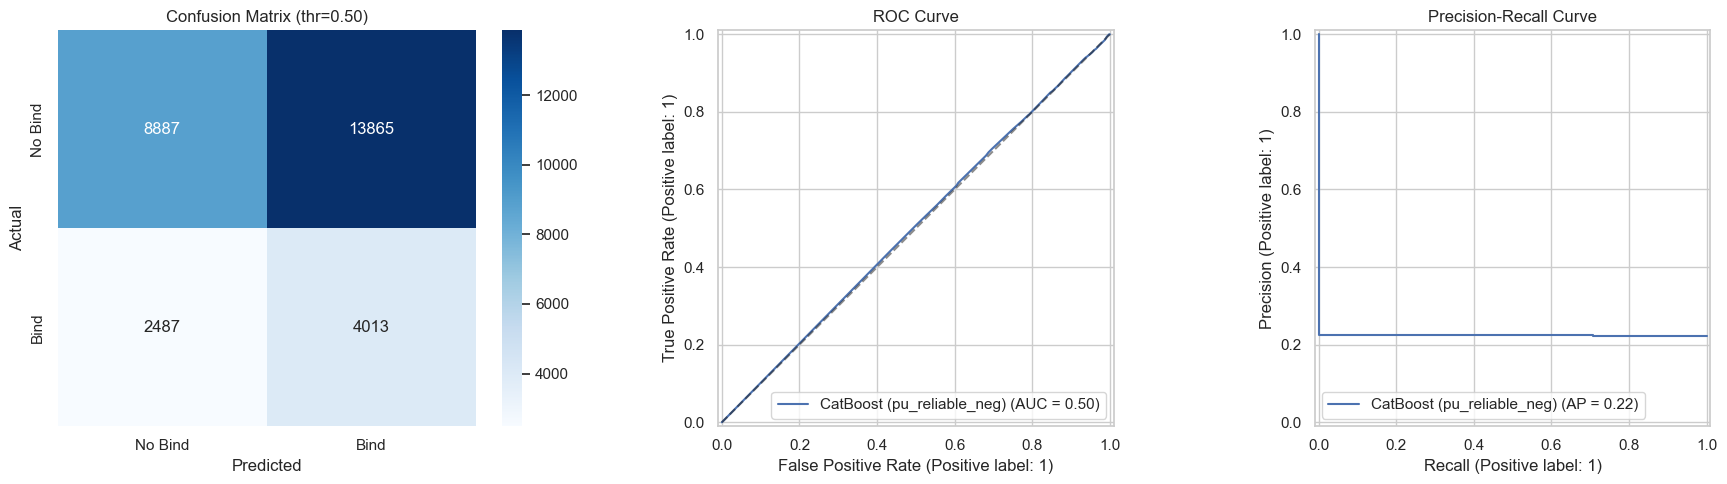

In [6]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Bind", "Bind"],
            yticklabels=["No Bind", "Bind"], ax=axes[0])
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_title(f"Confusion Matrix (thr={PRED_THRESHOLD:.2f})")

RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1], name=f"CatBoost ({selected_model_name})")
axes[1].set_title("ROC Curve")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.5)

PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=axes[2], name=f"CatBoost ({selected_model_name})")
axes[2].set_title("Precision-Recall Curve")

plt.tight_layout()
plt.savefig(MODELS_DIR / "agent2_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Bind Score Distribution

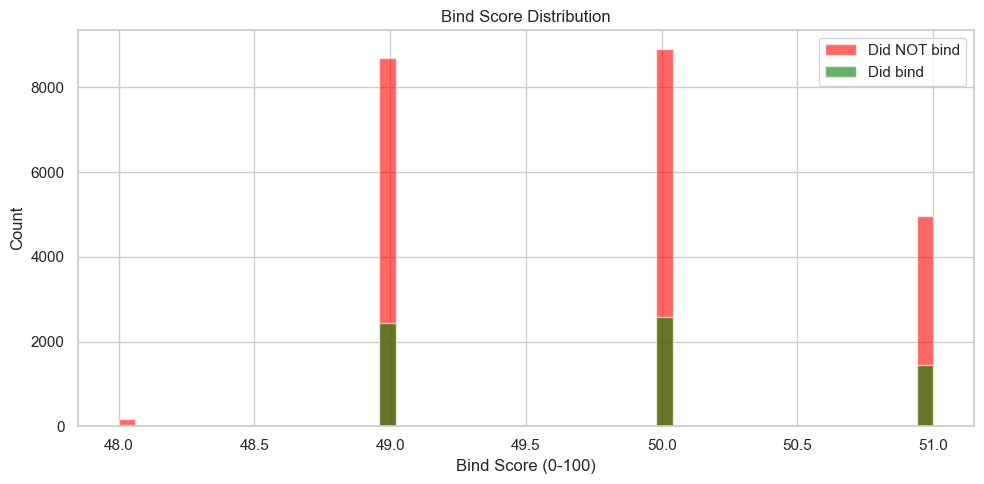

Mean bind score — Did NOT bind: 49.8
Mean bind score — Did bind:     49.8


In [7]:
bind_scores = (y_prob * 100).astype(int)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(bind_scores[y_test == 0], bins=50, alpha=0.6, color="red", label="Did NOT bind")
ax.hist(bind_scores[y_test == 1], bins=50, alpha=0.6, color="green", label="Did bind")
ax.set_xlabel("Bind Score (0-100)")
ax.set_ylabel("Count")
ax.set_title("Bind Score Distribution")
ax.legend()
plt.tight_layout()
plt.savefig(MODELS_DIR / "agent2_bind_score_dist.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Mean bind score — Did NOT bind: {bind_scores[y_test == 0].mean():.1f}")
print(f"Mean bind score — Did bind:     {bind_scores[y_test == 1].mean():.1f}")

## 5. Explainability: SHAP

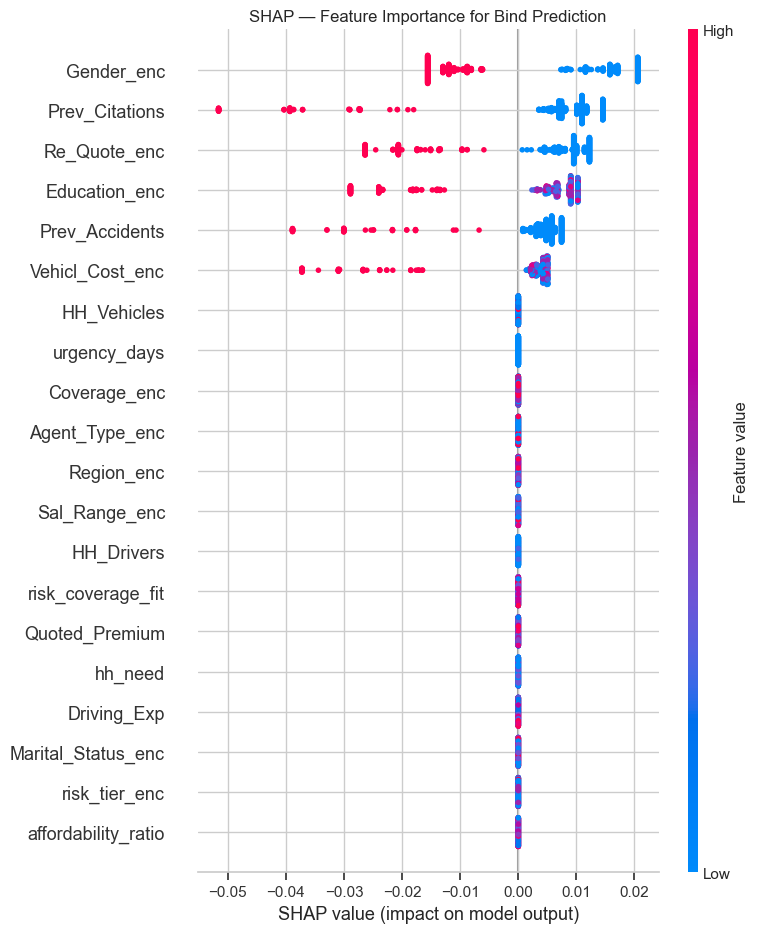


Bind probability: 0.5063 (score: 50)
Top SHAP features:
  Re_Quote_enc: -0.0264
  Gender_enc: +0.0158
  Prev_Citations: +0.0101
  Education_enc: +0.0088
  Vehicl_Cost_enc: +0.0051


In [8]:
import shap

explainer = shap.TreeExplainer(model)
X_sample = X_test.sample(n=min(500, len(X_test)), random_state=42)
shap_values = explainer.shap_values(X_sample)

if isinstance(shap_values, list):
    shap_bind = shap_values[1]
else:
    shap_bind = shap_values

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_bind, X_sample, show=False)
plt.title("SHAP — Feature Importance for Bind Prediction")
plt.tight_layout()
plt.savefig(MODELS_DIR / "agent2_shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

sample_row = X_test.iloc[[0]]
prob = model.predict_proba(sample_row)[0, 1]
sv_single = explainer.shap_values(sample_row)
if isinstance(sv_single, list):
    bind_shap = sv_single[1][0]
else:
    bind_shap = sv_single[0]
paired = sorted(zip(FEATURES, bind_shap), key=lambda p: abs(p[1]), reverse=True)
print(f"\nBind probability: {prob:.4f} (score: {int(prob*100)})")
print("Top SHAP features:")
for name, val in paired[:5]:
    print(f"  {name}: {val:+.4f}")

## 6. Explainability: LIME

Bind probability: 0.5063

LIME explanation:
  Prev_Citations <= 0.00: +0.0153
  Prev_Accidents <= 0.00: +0.0109
  Re_Quote_enc > 0.00: -0.0093
  Gender_enc <= 0.00: +0.0089
  Education_enc <= 1.00: +0.0029
  Vehicl_Cost_enc > 2.00: -0.0026
  HH_Drivers <= 1.00: +0.0003
  1.00 < risk_coverage_fit <= 2.00: -0.0002


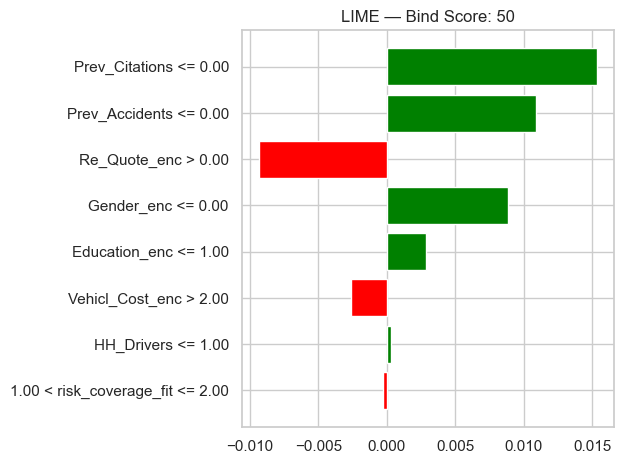

In [9]:
from lime.lime_tabular import LimeTabularExplainer

lime_explainer = LimeTabularExplainer(
    X_train_sm.values,
    feature_names=FEATURES,
    class_names=["No Bind", "Bind"],
    mode="classification",
    random_state=42,
)

sample_idx = 0
lime_exp = lime_explainer.explain_instance(
    X_test.iloc[sample_idx].values,
    model.predict_proba,
    num_features=8,
    top_labels=1,
)

pred_prob = model.predict_proba(X_test.iloc[[sample_idx]])[0, 1]
available_labels = list(lime_exp.local_exp.keys())
label_to_show = 1 if 1 in available_labels else available_labels[0]
print(f"Bind probability: {pred_prob:.4f}")
print(f"\nLIME explanation:")
for feat, weight in lime_exp.as_list(label=label_to_show):
    print(f"  {feat}: {weight:+.4f}")

fig = lime_exp.as_pyplot_figure(label=label_to_show)
plt.title(f"LIME — Bind Score: {int(pred_prob*100)}")
plt.tight_layout()
plt.savefig(MODELS_DIR / "agent2_lime_example.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Explainability: Anchors (IF-THEN Rules)

In [10]:
import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
logging.getLogger("alibi").setLevel(logging.WARNING)

from alibi.explainers import AnchorTabular

anchor_explainer = AnchorTabular(
    predictor=model.predict,
    feature_names=FEATURES,
)
anchor_explainer.fit(X_train_sm.values, disc_perc=(25, 50, 75))

sample_idx = 0
# Lower threshold (0.75) so we get a rule more often; default 0.95 can fail on some samples
explanation = anchor_explainer.explain(
    X_test.iloc[sample_idx].values,
    threshold=0.75,
)

pred = model.predict(X_test.iloc[[sample_idx]])[0]
anchor_rule = " AND ".join(explanation.anchor) if explanation.anchor else "No stable rule found"
print(f"Predicted: {'Bind' if pred == 1 else 'No Bind'}")
print(f"\nAnchor Rule: {anchor_rule}")
print(f"Precision: {explanation.precision:.4f}")
print(f"Coverage:  {explanation.coverage:.4f}")

Predicted: Bind

Anchor Rule: Gender_enc <= 0.00
Precision: 0.8564
Coverage:  0.5841


## 8. Explainability: DiCE Counterfactuals

"What would need to change for this quote to convert?" — the most actionable insight for agents.

In [11]:
import dice_ml


class ModelWrapper:
    """Converts string categoricals back to int for DiCE (model expects numeric)."""

    def __init__(self, model, feature_names, categorical_features):
        self.model = model
        self.feature_names = feature_names
        self.categorical_features = categorical_features

    def predict_proba(self, X):
        if isinstance(X, np.ndarray):
            X = pd.DataFrame(X, columns=self.feature_names)
        df = X.copy()
        for col in self.categorical_features:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype(int)
        return self.model.predict_proba(df)

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] > 0.5).astype(int)


train_dice = X_train.copy()
train_dice["Policy_Bind_enc"] = y_train.values.astype(int)

# Continuous: can be perturbed. Categorical: encoded (0,1,2,...) — must stay discrete
continuous_features = [
    "urgency_days",
    "HH_Drivers",
    "HH_Vehicles",
    "Quoted_Premium",
    "Driver_Age",
    "Driving_Exp",
    "Prev_Accidents",
    "Prev_Citations",
] + ENGINEERED
categorical_features = [
    f for f in FEATURES
    if f not in continuous_features and f != "Policy_Bind_enc"
]

# Categoricals as strings so DiCE matches allowed categories (avoids dtype errors)
for col in categorical_features:
    train_dice[col] = train_dice[col].astype(int).astype(str)

d = dice_ml.Data(
    dataframe=train_dice,
    continuous_features=continuous_features,
    categorical_features=categorical_features,
    outcome_name="Policy_Bind_enc",
)

model_wrapper = ModelWrapper(model, FEATURES, categorical_features)
m = dice_ml.Model(model=model_wrapper, backend="sklearn", model_type="classifier")
dice_exp = dice_ml.Dice(d, m, method="genetic")

# permitted_range: restrict categoricals to observed values
permitted_range = {
    col: [str(int(x)) for x in sorted(train_dice[col].dropna().unique().astype(int).tolist())]
    for col in categorical_features
}

sample_row = X_test.iloc[[0]].copy()
pred = model.predict(sample_row)[0]
desired = 1 if pred == 0 else 0

# Convert categoricals to strings for DiCE (after getting pred from numeric version)
for col in categorical_features:
    sample_row[col] = str(int(sample_row[col].iloc[0]))

print(f"Original: {'Bind' if pred == 1 else 'No Bind'} (score: {int(model.predict_proba(X_test.iloc[[0]])[0,1]*100)})")
print(f"Desired: {'Bind' if desired == 1 else 'No Bind'}")
try:
    cf = dice_exp.generate_counterfactuals(
        sample_row,
        total_CFs=3,
        desired_class=desired,
        permitted_range=permitted_range,
    )
    print(f"\nCounterfactual examples:")
    cf.visualize_as_dataframe(show_only_changes=True)
except Exception as e:
    print(f"DiCE could not generate counterfactuals for this sample: {e}")

Original: Bind (score: 50)
Desired: No Bind


100%|██████████| 1/1 [00:00<00:00,  1.97it/s]


Counterfactual examples:
Query instance (original outcome : 1)


,Re_Quote_enc,urgency_days,Coverage_enc,Agent_Type_enc,Region_enc,Sal_Range_enc,HH_Drivers,HH_Vehicles,Quoted_Premium,Vehicl_Cost_enc,...,Prev_Accidents,Prev_Citations,Gender_enc,Marital_Status_enc,Education_enc,risk_tier_enc,affordability_ratio,hh_need,risk_coverage_fit,Policy_Bind_enc
0,1,59,1,0,1,1,1,2,773.690002,3,...,0,0,0,3,1,1,-0.25,0.0,2,1



Diverse Counterfactual set (new outcome: 0.0)


,Re_Quote_enc,urgency_days,Coverage_enc,Agent_Type_enc,Region_enc,Sal_Range_enc,HH_Drivers,HH_Vehicles,Quoted_Premium,Vehicl_Cost_enc,...,Prev_Accidents,Prev_Citations,Gender_enc,Marital_Status_enc,Education_enc,risk_tier_enc,affordability_ratio,hh_need,risk_coverage_fit,Policy_Bind_enc
0,-,-,-,1,2,-,-,-,-,2,...,-,-,1,-,2,-,-0.2,-,-,0
0,-,-,-,-,2,-,-,1,-,0,...,-,-,1,-,-,-,-0.2,-,-,0
0,-,-,0,-,5,0,-,-,-,-,...,-,-,1,0,-,-,0.0,-,1,0


## 9. Save Model & Explainers

In [ ]:
joblib.dump(model, MODELS_DIR / "conversion_model.joblib")
joblib.dump(explainer, MODELS_DIR / "conversion_explainer.joblib")

# Save the feature engineering function so backend can apply it at inference
joblib.dump(add_domain_features, MODELS_DIR / "add_domain_features_fn.joblib")

# XAI bundle: everything the backend needs to run LIME, Anchors, DiCE at inference
rng = np.random.RandomState(42)
sample_size = min(1000, len(X_train_sm))
sample_idx = rng.choice(len(X_train_sm), sample_size, replace=False)

dice_sample_size = min(5000, len(train_dice))
dice_sample_idx = rng.choice(len(train_dice), dice_sample_size, replace=False)

conversion_xai_bundle = {
    # LIME / Anchors: need a sample of training data (SMOTE-resampled)
    "train_data": X_train_sm.values[sample_idx],
    # DiCE: training DataFrame with outcome column (categoricals as strings)
    "dice_train_df": train_dice.iloc[dice_sample_idx].reset_index(drop=True),
    "dice_continuous_features": continuous_features,
    "dice_categorical_features": categorical_features,
    "dice_outcome_name": "Policy_Bind_enc",
    # Feature metadata
    "feature_names": FEATURES,
    "base_features": BASE_FEATURES,
    "engineered_features": ENGINEERED,
    "class_names": ["No Bind", "Bind"],
    # Pure-ML scoring config
    "prediction_threshold": PRED_THRESHOLD,
    "threshold_sweep_scores": thr_df.to_dict(orient="records"),
    "premium_advisor_threshold": RECOMMENDED_PA_THRESHOLD,
    # Tracking which ML variant is persisted
    "selected_model_name": selected_model_name,
    "ml_variant_scores": results_df.to_dict(orient="records"),
    "pu_sweep_scores": pu_sweep_df.to_dict(orient="records"),
    "best_pu_quantile": reliable_neg_quantile,
    "best_pu_cutoff": reliable_neg_cutoff,
}

joblib.dump(conversion_xai_bundle, MODELS_DIR / "conversion_xai_bundle.joblib")

print("Saved: conversion_model, conversion_explainer, conversion_xai_bundle, add_domain_features_fn")
print(f"Selected ML variant: {selected_model_name}")
print(f"Prediction threshold: {PRED_THRESHOLD:.2f}")
print(f"Features: {len(FEATURES)} ({len(BASE_FEATURES)} base + {len(ENGINEERED)} engineered)")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")
print(f"PR-AUC:  {average_precision_score(y_test, y_prob):.4f}")

Saved: conversion_model, conversion_explainer, conversion_xai_bundle, add_domain_features_fn
Selected ML variant: pu_reliable_neg
Prediction threshold: 0.50
Features: 21 (18 base + 3 engineered)
ROC-AUC: 0.5042
PR-AUC:  0.2242
